In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import os

load_dotenv()

True

In [2]:
from langchain_cerebras import ChatCerebras

llm = ChatCerebras(
    model="qwen-3-235b-a22b-instruct-2507",
    api_key=os.getenv("CEREBRAS_API_KEY"),
    temperature=0.7,
    max_tokens=100 
)

chat=llm

In [3]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] # means this BaseMessage contains all type of messages like HumanMessage,SystemMessage,AIMessage and we can use add_messages(as a reducer by langraph instaead of langchain operator) to add messages to the list

In [4]:
def chat_node(state:ChatState)->ChatState:
    message=state['messages']
    
    response=chat.invoke(message)
    
    return {'messages':[response]}

In [5]:
checkpointer=InMemorySaver()

graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile(checkpointer=checkpointer)

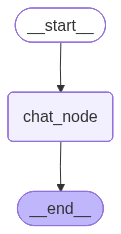

In [6]:
chatbot

In [7]:
# initial_state={
#     'messages':[HumanMessage(content="What is Langgraph?")]
# }

# chatbot.invoke(initial_state)

In [8]:
thread_id='1' 
while True:
    
    user_message=input('Type here')
    print('User:',user_message)
    
    if user_message.strip().lower() in ['exit','quit','end']:
        print('Ending chat')
        break
    config={
        'configurable':{
            'thread_id':thread_id
        }
    }
    response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('AI :',response['messages'][-1].content)

User: exit
Ending chat


In [9]:
#for persistance we have to first import checkpointer from langgraph.checkpoint.memory import MemorySaver and then create an object of MemorySaver class and then we can pass this object to the config of the chatbot.invoke method as shown below


In [13]:
# for chatgpt like typewritter effect which is called streaming ,
thread_id='1' 
while True:
    
    user_message=input('Type here')
    print('User:',user_message)
    print('AI :')
    if user_message.strip().lower() in ['exit','quit','end']:
        print('Ending chat')
        break
    config={
        'configurable':{
            'thread_id':thread_id
        }
    }
    ########################################   here below is change
    for message_chunk,metadata in chatbot.stream({'messages':[HumanMessage(content=user_message)]},config=config,stream_mode="messages"):
        if message_chunk.content:
            print(message_chunk.content,end=" ",flush=True)

User: what is cr7
AI :
** CR7** refers  to **Cristiano Ronaldo**, one of  the greatest football ( soccer ) players of all time. The name " CR7" is a  combination of his initials — ** C**ristiano **R**onal do — and his famous  jersey number , **7**, which  he has worn  throughout most of his professional career .

Born on **February  5, 1985**, in Funchal, Made ira, Portugal, Cristiano Ronaldo began his football journey at User: explain cr7
AI :
** CR7** stands for **Cristiano Ronaldo **,  the  world -renowned Portuguese professional footballer. The term "CR7" is derived from his name —  ** C ** rist iano  ** R**onaldo — and his iconic jersey number, **7**, which he has famously worn for most of his career.

### Who is Cristiano Ronaldo?

Cristiano Ronaldo  dos Santos Aveiro, commonly known as Cristiano Ronaldo or simply CR7, was born on **February 5, 19 User: explain cr7 in 400words
AI :
** CR7: The Legend of  Cristiano Ronaldo (400 Words)**

"CR 7" is the globally recognized  nickname

RateLimitError: Error code: 429 - {'message': "We're experiencing high traffic right now! Please try again soon.", 'type': 'too_many_requests_error', 'param': 'queue', 'code': 'queue_exceeded'}